In [117]:
import torch
import open3d as o3d
import numpy as np
from tqdm import tqdm

pcd0 = o3d.io.read_point_cloud('0_pc.pcd')
points = np.asarray(pcd0.points)
pcd0 = torch.from_numpy(points).float().unsqueeze(0).transpose(1,2)
pcd1 = o3d.io.read_point_cloud('0_pc2.pcd')
points = np.asarray(pcd1.points)
pcd1 = torch.from_numpy(points).float().unsqueeze(0).transpose(1,2)

def knn(x, k):
    inner = -2*torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
 
    idx = pairwise_distance.topk(k=k, dim=-1)[1]   # (batch_size, num_points, k)
    return idx

neighbor_count = torch.zeros(pcd0.size(2), dtype=torch.int)

knn_matrix = knn(pcd0, k)

print('1')
k = 20
neighbors = knn(pcd0, k)[:,0].squeeze(0) # 20
for i in tqdm(neighbors):
    if i != 0 : neighbor_count[i] += 1

print('2')
new_neighbors2 = torch.tensor([]).type(torch.int)
for j in tqdm(neighbors): # 20
    neighbors2 = knn_matrix[:,j].squeeze(0) # 20 * 20
    for i in neighbors2:
        if j != i : neighbor_count[i] += 1
    new_neighbors2 = torch.cat([new_neighbors2, neighbors2])

print('3')
new_neighbors3 = torch.tensor([]).type(torch.int)
for j in tqdm(new_neighbors2): # 20 * 20
    neighbors3 = knn_matrix[:,j].squeeze(0) # 20 * 20 * 20
    for i in neighbors3:
        if j != i : neighbor_count[i] += 1
    new_neighbors3 = torch.cat([new_neighbors3, neighbors3])

print('4')
new_neighbors4 = torch.tensor([]).type(torch.int)
for j in tqdm(new_neighbors3): # 20 * 20 * 20
    neighbors4 = knn_matrix[:,j].squeeze(0) # 20 * 20 * 20 * 20
    for i in neighbors4:
        if j != i : neighbor_count[i] += 1
    new_neighbors4 = torch.cat([new_neighbors4, neighbors4])

# print('5')
# new_neighbors5 = torch.tensor([]).type(torch.int)
# for j in tqdm(new_neighbors4): # 20 * 20 * 20 * 20
#     neighbors5 = knn_matrix[:,j].squeeze(0) # 20 * 20 * 20 * 20 * 20
#     for i in neighbors5:
#         if j != i : neighbor_count[i] += 1
#     new_neighbors5 = torch.cat([new_neighbors5, neighbors5])

1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 40920.04it/s]


2


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 4166.18it/s]


3


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 4615.43it/s]


4


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:59<00:00, 135.34it/s]


In [82]:
import torch
import numpy as np
import pickle

with open('./debug.pickle', 'rb') as f:
    data = pickle.load(f)
pcd0 = data['src_pcd_raw'].cpu().detach()
pcd1 = data['trg_pcd_raw'].cpu().detach()

In [83]:
import numpy as np
from scipy.spatial import KDTree

def find_k_nearest_neighbors(point_cloud, idx, k):
    tree = KDTree(point_cloud)
    distances, indices = tree.query(point_cloud[idx], k=k+1)  # k+1은 자기 자신을 제외하기 위해
    return indices[1:]  # 첫 번째는 자기 자신이므로 제외

In [92]:
# Parameters
k = 20
num_points = pcd1.size(0)

In [93]:
neighbor_idx_stage1 = find_k_nearest_neighbors(pcd1, 0, k)

In [94]:
neighbor_idx_stage2 = []
for i in neighbor_idx_stage1:
    neighbor_idx_stage2.append(find_k_nearest_neighbors(pcd1, i, k))
neighbor_idx_stage2 = np.concatenate(neighbor_idx_stage2)

In [95]:
neighbor_idx_stage3 = []
for i in neighbor_idx_stage2:
    neighbor_idx_stage3.append(find_k_nearest_neighbors(pcd1, i, k))
neighbor_idx_stage3 = np.concatenate(neighbor_idx_stage3)

In [96]:
frequencies = np.bincount(neighbor_idx_stage3, minlength=num_points)

In [97]:
(frequencies == 0).sum()

153

In [118]:
(neighbor_count == 0).sum()

tensor(2334)

In [123]:
neighbor_count.size()

torch.Size([2556])

In [124]:
neighbor_count

tensor([4078,    0,    0,  ...,    0,    0,    0], dtype=torch.int32)

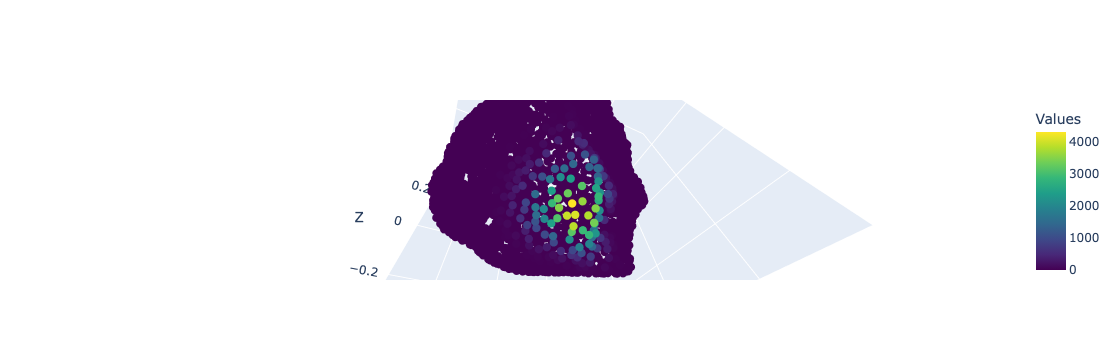

In [125]:
import torch
import plotly.graph_objects as go
import numpy as np

# 포인트 클라우드를 numpy 배열로 변환
points_np = pcd0.squeeze(0).numpy()  # 3xN 배열
values_np = neighbor_count.numpy()  # N 배열

# plotly를 이용한 시각화
fig = go.Figure(data=[go.Scatter3d(
    x=points_np[0],  # X 좌표
    y=points_np[1],  # Y 좌표
    z=points_np[2],  # Z 좌표
    mode='markers',
    marker=dict(
        size=3,
        color=values_np,  # 색상 값
        colorscale='Viridis',  # 색상 스케일
        colorbar=dict(title='Values'),  # 색상바 제목
        showscale=True
    )
)])

fig.update_layout(scene=dict(
    xaxis_title='X',
    yaxis_title='Y',
    zaxis_title='Z'
))

fig.show()